<a href="https://colab.research.google.com/github/while-true-study/vision-model-playground/blob/main/notebooks/02_segmentation_sam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install -q transformers

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from transformers import SamModel, SamProcessor
import torch
from PIL import Image
from diffusers.utils import load_image

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SamModel.from_pretrained("facebook/sam-vit-base").to(device)
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

img = load_image(
    "https://huggingface.co/ybelkada/segment-anything/resolve/main/assets/car.png"
).convert("RGB")

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

In [3]:
input_points = [[[450, 600]]]
inputs = processor(img, input_points=input_points, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)
scores = outputs.iou_scores
print(scores)

tensor([[[0.9057, 0.9562, 0.9668]]])


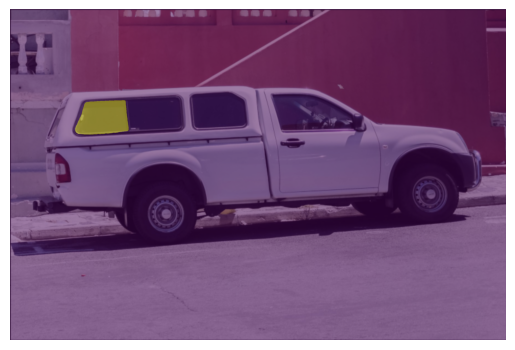

In [4]:
import numpy as np
import matplotlib.pyplot as plt

mask = masks[0][0][scores.argmax()].numpy()
plt.imshow(img); plt.imshow(mask, alpha=0.5); plt.axis("off"); plt.show()

In [5]:
input_points = [[[250, 180]]]
inputs = processor(img, input_points=input_points, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)
scores = outputs.iou_scores
print(scores)

tensor([[[0.6692, 0.8945, 0.8941]]])


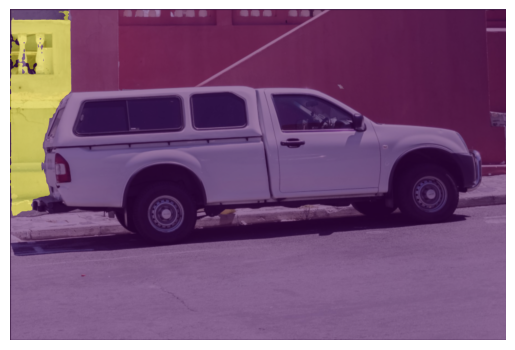

In [6]:
import numpy as np
import matplotlib.pyplot as plt

mask = masks[0][0][scores.argmax()].numpy()
plt.imshow(img); plt.imshow(mask, alpha=0.5); plt.axis("off"); plt.show()

In [11]:
!git config --global user.email "aodaod128@naver.com"
!git config --global user.name "while-true-study"

In [18]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address
